# Лабораторна #1: Класифікація текстів

У цьому завданні ми натренуємо модель для визначення **тональності тексту**. Наша модель отримуватиме на вхід відгук на фільм й видаватиме один з двох класів: позитивний (фільм сподобався) чи негативний (фільм не сподобався).

# 1 Дані

Існує багато датасетів для класифікації текстів. Зручно переглянути їх можна на сервісі [Hugging Face Datasets](https://huggingface.co/datasets?task_categories=task_categories:text-classification).

Для цієї лабораторної ми візьмемо один з класичних датасетів аналізу тональності тексту, [IMDB](https://huggingface.co/datasets/stanfordnlp/imdb). Цей датасет містить 50,000 позначених відгуків на фільми та додатковий непозначений розділ. Кожен позначений відгук відноситься до одного з двох класів:
* позитивний (фільм сподобався);
* негативний (фільм не сподобався).

Для тренування використовується лише 25,000 відгуків, решта 25,000 призначена для оцінки моделі.


Завантажімо дані за допомогою бібліотеки Hugging Face [Datasets](https://huggingface.co/docs/datasets/loading):

In [ ]:
!pip install --quiet datasets spacy pystemmer matplotlib "scikit-learn>=1.8,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 747.7/747.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.4 MB/s eta 0:00:00


In [ ]:
import datasets

In [ ]:
# Метод `load_dataset` завантажує потрібні дані з інтернету та кешує їх
# локально. Повторний виклик цього коду перевикористає вже завантажені
# дані.
imdb = datasets.load_dataset("stanfordnlp/imdb")

`imdb`, як і будь-який інший датасет бібліотеки `datasets`, це словник.
Ключами в ньому є назви розділів (`train`, `test`, `unsupervised`), а значеннями --
об'єкт `Dataset`, який вже містить дані:

In [ ]:
imdb

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [ ]:
print(imdb.keys())
train_data = imdb["train"]
train_data

dict_keys(['train', 'test', 'unsupervised'])


Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [ ]:
# Можемо трактувати `train_data` як масив записів:
train_data[100]["text"]

"Terrible movie. Nuff Said.<br /><br />These Lines are Just Filler. The movie was bad. Why I have to expand on that I don't know. This is already a waste of my time. I just wanted to warn others. Avoid this movie. The acting sucks and the writing is just moronic. Bad in every way. The only nice thing about the movie are Deniz Akkaya's breasts. Even that was ruined though by a terrible and unneeded rape scene. The movie is a poorly contrived and totally unbelievable piece of garbage.<br /><br />OK now I am just going to rag on IMDb for this stupid rule of 10 lines of text minimum. First I waste my time watching this offal. Then feeling compelled to warn others I create an account with IMDb only to discover that I have to write a friggen essay on the film just to express how bad I think it is. Totally unnecessary."

In [ ]:
# label=0 -- негативний відгук
# label=1 -- позитивний відгук
train_data[100]["label"]

0

In [ ]:
#########для себе
for i in range(13000, 13005):
  print(train_data[i]["text"])
  print(train_data[i]["label"])

Visually stunning and full of Eastern Philosophy, this amazing martial arts fantasy is brought to you by master director Tsui Hark, the man behind some of the best films Hong Kong cinema has produced. The special effects are beautiful and imaginative. The plot is a bit on the cerebral side, but is a refreshing change from films that treat their audience as if they were morons. If thinking is not your forte, however, this may not be your movie. Maybe you should go see the latest from the Hollywood studio's no brain club, but if you are looking for something more, he's where you will find it.
1
This is an incredible comeback from movie director mastermind, Tsui Hark. It is one of a few movies that deserves to come a face to face match to Steven Chow's Shaolin Soccer. From the moment the movie started,there was astronishing backdrops at every edge which were<br /><br />deplicted with superb style. If you are a science fiction or chinese martial arts "geek", you'll love the excessive amoun

In [ ]:
####для себе
train_data["text"]

Column(['I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far bet

# 2 Підготовка тексту (text preprocessing)

Спочатку ми маємо підготувати текст до подачі в модель класифікації.

### 2.1 Токенізація

Існує багато бібліотек для токенізації. [SpaCy](https://spacy.io/) та [NLTK](https://www.nltk.org/) -- це два великих пакети, що містять в собі багато інструментів для опрацювання текстів, тому числі й токенізатори.

Наступна функція токенізує текст за допомогою spaCy:

In [ ]:
!pip install --quiet spacy

In [ ]:
import spacy
import tqdm
from typing import List, Tuple

# Spacy підтримує багато мов. Зараз нам потрібна англійська
spacy_nlp = spacy.blank("en")


def tokenize_spacy(text: str) -> List[str]:
  """Tokenize string with SpaCy. """

  tokens = spacy_nlp.tokenizer(text)
  return [str(token) for token in tokens]


def tokenize(text: str) -> List[str]:
  return tokenize_spacy(text)


tokenize_spacy("I can't find my $25!  http://google.com/ oleksiy.syvokon@gmail.com ")

['I',
 'ca',
 "n't",
 'find',
 'my',
 '$',
 '25',
 '!',
 ' ',
 'http://google.com/',
 'oleksiy.syvokon@gmail.com']

Свій токенізатор можна побудувати на регулярних виразах. Найпростіший, хоча й не досконалий, виглядає так:

In [ ]:
import re

def tokenize_re(text: str) -> List[str]:
  return re.findall(r"\w+", text)

tokenize_re("I can't find my $25! :)  http://google.com/ oleksiy.syvokon@gmail.com ")

['I',
 'can',
 't',
 'find',
 'my',
 '25',
 'http',
 'google',
 'com',
 'oleksiy',
 'syvokon',
 'gmail',
 'com']

Такий простий токенізатор далекий від ідеалу. Він пропускає пунктуацію,
неправильно розбиває слова з апосторофом, не знає про існування URL та emoji тощо.

Для того, щоб покрити більше випадків, доведеться ускладнювати regexp.
Ось реальний приклад, наскільки складним це може стати: [`nltk.TweeterTokenizer`](https://github.com/nltk/nltk/blob/637af5380d6071517a5f0d224649e5c3560b5f91/nltk/tokenize/casual.py#L118)

### 2.2 Стемінг

In [ ]:
!pip install pystemmer

In [ ]:
import Stemmer #працює через алгоритми Snowball / Porter2
from typing import List

def stem(tokens: List[str]) -> List[str]:
  """Lower-case and stem tokens. """

  stemmer = Stemmer.Stemmer("english")
  tokens = [tok.lower() for tok in tokens]
  return stemmer.stemWords(tokens)

example_tokens = tokenize(train_data[2]["text"])
stemmed_tokens = stem(example_tokens)
##повна версія речення для порівняння
print(train_data[2]["text"])
print(" ".join(stemmed_tokens))


If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any discernable motive. The viewer comes away with no new perspectives (unless one comes up with one while one's mind wanders, as it will invariably do during this pointless film).<br /><br />One might better spend one's time staring out a window at a tree growing.<br /><br />
if onli to avoid make this type of film in the futur . this film is interest as an experi but tell no cogent story.<br /><br />one might feel virtuous for sit thru it becaus it touch on so mani import issu but it doe so without ani discern motiv . the viewer come away with no new perspect ( unless one come up with one while one 's mind wander , as it will invari do dure this pointless film).<br /><br />one might better spend one 's time stare out a window at a tree g

In [ ]:
# Знайдемо стеми деяких слів
for word in ("sing", "sings", "singing", "singer", "singers"):
  stemmed = stem([word])[0]
  print(f"{word:<20}   =>   {stemmed}")

sing                   =>   sing
sings                  =>   sing
singing                =>   sing
singer                 =>   singer
singers                =>   singer


Токенізуємо та стемінгуємо текст, щоб оцінити вплив стемінгу на розмір словника.

In [ ]:
from tqdm import tqdm

all_tokens = []
all_tokens_stemmed = []
for doc in tqdm(train_data):
  doc_tokens = tokenize(doc["text"])
  all_tokens += doc_tokens
  all_tokens_stemmed += stem(doc_tokens)

print("Original unique tokens: {:,}".format(len(set(all_tokens))))
print("Stemmed  unique tokens: {:,}".format(len(set(all_tokens_stemmed))))

100%|██████████| 25000/25000 [01:00<00:00, 412.36it/s]


Original unique tokens: 121,065
Stemmed  unique tokens: 76,559


Як бачимо, кількість унікальних токенів значно зменшилася після стемінгу.

### 2.3 Стоп-слова


Деякі слова зустрічаються часто, але не несуть смислового навантаження. Їх можна видалити з тексту.

Існують готові спискі стоп-слів. Їх можна брати за основу, але варто переглядати
під кожну конкретну задачу. Наприклад, для нашої задачі аналізу тональності
тексту, слова "not", "don't", "like" є важливими, хоча вони присутні в більшості списків стоп-слів.

Зараз ми вважатимемо кілька частотних слів стоп-словами:

In [ ]:
STOP_WORDS = stem(["the", "and", "a", "of", "to", "is", "in", "that", "this", "was", "as", "with", "for", "you", "are", "it"])

def remove_stop_words(tokens: List[str]) -> List[str]:
  return [token for token in tokens if token not in STOP_WORDS]

remove_stop_words("and this was fantastic".split())

['fantastic']

### 2.4 Збираємо докупи

Наш невеличкий ланцюжок перетворень складається з трьох кроків: токенізація, стемінг та видалення стоп-слів. Ці три функції мусимо викликати для будь-якого вхідного тексту. Якщо забути зробити один з цих кроків, то модель продовжить працювати, але з гіршою якістю.

Хорошею практикою є збирання усіх кроків в одну функцію. В бібліотеках це називається preprocessing pipeline або pipes.

In [ ]:
def preprocess(text: str) -> List[str]:
  tokens = tokenize(text)
  tokens = stem(tokens)
  tokens = remove_stop_words(tokens)
  return tokens

preprocess("I likes it!")

['i', 'like', '!']

### 2.5 Словник

Майже завжди в моделях NLP ми маємо справу з обмеженим набором слів (правильніше казати "токенів", бо до них також відносяться пунктуація, n-грами та спеціальні символи). Цей набір токенів називається словником (vocabulary).

Перед тим, як розпочати тренування моделі, ми маємо визначитися, якого розміру буде наш словник та що в нього включати. Великий словник означає, що наша модель матиме багато ознак (features), що підвищує ризик перенавчання (overfitting). Маленький словник призведе до того, що багато вхідних слів, які не потрапили до словника, будуть просто пропущені моделю і можлива ситуація недонавчання (underfit) -- модель стає надто простою для адекватного моделювання задачі.

Простих рецептів по вибору розміру словника немає. В контексті глибинного навчання зазвичай використовується від 8,000 до 64,000 токенів. Для простих лінійних класифікаторов типу того, що ми його зараз будуємо, доречними будуть значення в районі кількох тисяч. Можна вважати розмір словника гіперпараметром та підібрати оптимальне значення кросвалідацією. Поки що зупинимося на розмірі в $N=5000$ токенів.

Як правило, в словник включають начастотніші $N$ токенів, які зустрілися в тренувальних даних. Зі словника можуть виключати пунктуацію та деякі стоп-слова, якщо вони не є корисними для конкретної задачі. Також в словник додають спеціальні токени, які позначають невідомі слова (`<UNK>`), початок та кінець речення (`<s>` та `</s>` або `<bos>`/`</eos>`).

#### 2.5.1 Розподіл слів

Подивимося на розподіл частот слів:

Top 50 most common tokens account for 47.041546% of tokens
Top 50 tokens are: [('the', 328829), (',', 275296), ('.', 236709), ('and', 162896), ('a', 161730), ('of', 145596), ('to', 135356), ('is', 110135), ('it', 101619), ('in', 92871), ('i', 82706), ('this', 73412), ('that', 73069), ('"', 63332), ("'s", 62111), ('-', 53554), ('/><br', 50935), ('movi', 50571), ('was', 50375), ('film', 47176), ('as', 46161), ('for', 43937), ('with', 43847), ('but', 41647), ('on', 33864), ('you', 33746), ('be', 33531), ('(', 33099), ("n't", 32846), (')', 32574), ('not', 31374), ('have', 30953), ('are', 30236), ('he', 29998), ('his', 29303), ('one', 27062), ('all', 23317), ('at', 23268), ('they', 22729), ('like', 22615), ('by', 22388), ('!', 21922), ('an', 21450), ('who', 21316), ('from', 20339), ('so', 19972), ('do', 18782), ('her', 18310), ('or', 17737), ('just', 17656)]


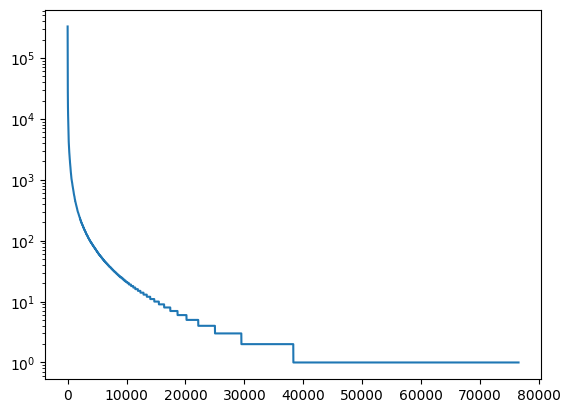

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Корпус вже токенізовано в all_tokens та all_tokens_stemmed
assert all_tokens
assert all_tokens_stemmed

# Злічимо усі токени
token_counts = Counter(all_tokens_stemmed)

# Подивимося на 50 найчастотніших токенів
most_common = token_counts.most_common(50)

most_common_count = sum(count for token, count in most_common)
all_count = sum(token_counts.values())
print(f"Top {len(most_common)} most common tokens account for {most_common_count / all_count:%} of tokens")
print(f"Top {len(most_common)} tokens are: {most_common}")

# Розподіл токенів за частотою
plt.yscale("log")
plt.plot(sorted(token_counts.values(), reverse=True))


##Закон Ціпфа - частота слова в природній мові обернено пропорційна до його рангу в частотному словнику (порядковому номеру при сортуванні за спаданням частот)
##(друге за частотою слово трапляється вдвічі ріже за перше, третє - втричі рідше за перше)

Щоб краще уявити собі нерівномірність цього розподілу, намалюємо його на лінійній, а не логаріфмічній шкалі:

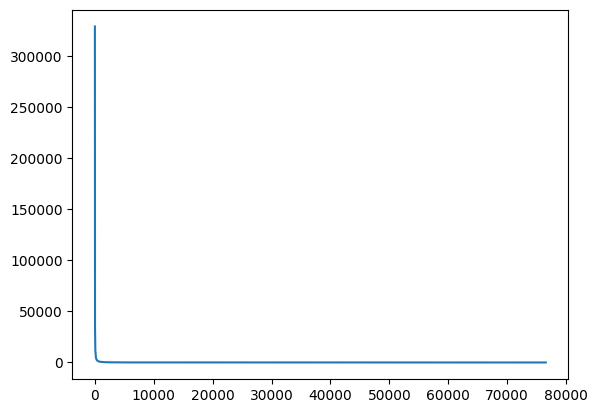

In [ ]:
plt.plot(sorted(token_counts.values(), reverse=True))

#### 2.5.2 Рідковживані слова

Залишимо лише ті слова, які зустрічаються щонайменше 5 разів. Також візьмемо `VOCAB_SIZE` найчастотніших слів.

In [ ]:
VOCAB_SIZE = 5000
MIN_COUNT = 5

print(f"Vocab size before filtering: {len(token_counts):,}")

vocab_list = [token for token, count in token_counts.most_common()
              if count >= MIN_COUNT
              and token not in STOP_WORDS]

print(f"Vocab size after filtering: {len(vocab_list):,}")

# Зараз vocab містить токени, відсортовані за частотою у порядку зменшення.
# Візьмемо лише частину з них
vocab_list = vocab_list[:VOCAB_SIZE]
print(f"Final vocab size: {len(vocab_list):,}")

Vocab size before filtering: 76,559
Vocab size after filtering: 22,154
Final vocab size: 5,000


In [ ]:
# Приклад токенів у словнику
vocab_list[4090:4100]

['distinguish',
 'map',
 '35',
 'bump',
 'molli',
 'profess',
 'cannon',
 'furi',
 'frankenstein',
 'crucial']

#### 2.5.3 Допоміжні функції

Є кілька операцій, які часто доводиться робити із словником:

- Отримати слово за його індексом
- Отримати індекс за словом

До того ж доводиться враховувати, що токена може й не бути в словнику. У такому випадку зазвичай повертається спеціальний токен `<unk>`.

Нижче ми загорнемо всі ці допоміжні функції у клас `Vocabulary`. Різні бібліотеки і фреймворки мають свої аналоги цього класу.

In [ ]:
class Vocabulary:

  def __init__(self, tokens, unk_token="<unk>"):
    self.unk_token = unk_token
    self.unk_index = 0
    self._itos = [unk_token] + tokens
    self._stoi = {token: index for index, token in enumerate(self._itos)}

  def stoi(self, token: str) -> int: #string-to-index - Перетворення токена в айді(число)
    """Return token index or `<unk>` index if `token` is not in the vocab.
    """
    return self._stoi.get(token, self.unk_index)


  def itos(self, index: int) -> str: #index-to-string - Перетворення айді(числа) в текстовий токен
    """Return token by its `index`.

    Raise LookupError if `index` is out of vocabulary range.
    """

    return self._itos[index]

  @property
  def tokens(self):
    return self._itos

  def __len__(self) -> int:
    return len(self._itos)


vocab = Vocabulary(vocab_list)
assert vocab.stoi("definitely-not-in-vocabulary") == vocab.unk_index
assert vocab.itos(vocab.stoi("dog")) == "dog"
print(f"Index of `dog` is {vocab.stoi('dog')}")
print(f"Token #42 is `{vocab.itos(42)}`")

Index of `dog` is 753
Token #42 is `what`


In [ ]:
#для себе
print(vocab.stoi("what"))
print(vocab.itos(753))

42
dog


Токени, яких немає в словнику, предсталяються спеціальним токеном `<unk>` (має індекс 0):

In [ ]:
s = "Hello NULP !".split()
[vocab.stoi(x.lower()) for x in s]

[4243, 0, 26]

# 3 Представлення тексту

## 3.1 One-hot

При one-hot кодуванні кожне слово представляється вектором, довжина якого дорівнює розміру словника. У цьому векторі всі елементи, крім одного, дорівнюють нулю. Єдина одиниця відповідає позиції слова у словнику.


In [ ]:
def one_hot(token: str, vocab: Vocabulary) -> List[int]:
    # Створюємо список нулів довжиною, що дорівнює розміру словника
    result = [0] * len(vocab) ##по факту довжина 5001 (бо ми взяли 5000 слів + на початку стоїть Unknown_Token)

    # Отримуємо індекс токена (слова) у словнику
    index = vocab.stoi(token)

    # Встановлюємо 1 на позиції, що відповідає індексу токена
    result[index] = 1

    return result

_test_vocab = Vocabulary(["cat", "dog"])
_test_vector = one_hot("dog", _test_vocab)
assert len(_test_vector) == len(_test_vocab)
assert sum(_test_vector) == 1
assert _test_vector[_test_vocab.stoi("dog")] == 1

In [ ]:
# Закодуємо слово "dog"
vector_dog = one_hot("dog", vocab)

# Перевіряємо довжину вектора (вона повинна дорівнювати розміру словника)
len(vector_dog)

5001

In [ ]:
# Виводимо перші 20 елементів вектора. Вектор розріджений, містить багато нулів.
vector_dog[:20]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
# Знаходимо позицію слова "dog" у словнику
vector_dog.index(1)

753

In [ ]:
# Перевіряємо, чи правильно закодовано слово, декодуючи його індекс назад у слово
vocab.itos(vector_dog.index(1))

'dog'

## 3.2 Bag-of-words

In [ ]:
def bag_of_words(tokens: List[str], vocab: Vocabulary) -> List[int]: ##Покомпонентна сума усіх One-Hot векторів для кожного токена
  result = [0] * len(vocab)

  for token in tokens:
    index = vocab.stoi(token)
    result[index] += 1

  return result

_test_vocab = Vocabulary(["like", "turtle"])
_test_bow = bag_of_words(["like", "like", "turtle"], _test_vocab)
assert _test_bow[_test_vocab.stoi("like")] == 2
assert sum(_test_bow) == 3

In [ ]:
tokens = preprocess("I like like turtles . . . ")
print(f"Tokenized: {tokens}")
vector_text = bag_of_words(tokens, vocab)
print(vector_text)

Tokenized: ['i', 'like', 'like', 'turtl', '.', '.', '.']
[1, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
bag_of_words(preprocess("turtles . . . like I like"), vocab)[:20]

[1, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

## 3.3 N-grams


"don't like" -> do, n't, like

I like it very much

1-ngram: I, like, it, very, much

2-ngram: "I like", "like it"

3-ngram: "I like it", "like it very", "it very much"





In [ ]:
def extract_ngrams(tokens: List[str], max_n: int, min_n: int = 1) -> List[str]:
    """Extract n-grams from `s`.

    Args:
        tokens: list of tokens.
        min_n: Minimum length of n-gram to extract.
        max_n: Maximum length of n-gram to extract.

    Return:
        list of ngrams, where each ngram is as a string.


    Example:
        >>> extract_ngrams("Hello world !".split(), 2)
        ['Hello', 'Hello world', 'world', 'world !', '!']

    """

    return list(extract_ngrams_iter(tokens, max_n, min_n))


def extract_ngrams_iter(tokens: List[str], max_n: int, min_n: int = 1):
    """Extract all ngrams from `s`, yielding them one by one.

    Example:
        >>> next(extract_ngrams_iter("Hello world !".split(), 2))
        'Hello'

    """

    for i in range(len(tokens)): ##індекс, з якого стартує n-грама
        for j in range(min_n, max_n + 1): ##скільки кроків від індексу(згори) треба зробити праворуч (які довжини n-грам розглядаємо) - декілька варіантів
            if i + j <= len(tokens):
                ngram = tokens[i : i + j]
                ngram = " ".join(ngram)
                yield ngram


_test_ngrams = extract_ngrams("hello world !".split(), 2)
assert _test_ngrams == ["hello", "hello world", "world", "world !", "!"]
_test_ngrams

['hello', 'hello world', 'world', 'world !', '!']

In [ ]:
# Побудуємо н-грамний словник
counts = Counter()
for doc in tqdm(train_data):
  tokens = preprocess(doc["text"])
  ngrams = extract_ngrams(tokens, 2)
  counts.update(ngrams)

ngrams_vocab = [token for token, count in counts.most_common() if count >= MIN_COUNT]
ngrams_vocab = ngrams_vocab[:VOCAB_SIZE]
ngrams_vocab = Vocabulary(ngrams_vocab)


100%|██████████| 25000/25000 [01:01<00:00, 409.26it/s]


In [ ]:
len(ngrams_vocab)

5001

In [ ]:
# Подивимося на приклади n-грам в нашому словнику:
[x for x in ngrams_vocab._itos ][1000:1020]

['respect',
 'say ,',
 '4',
 'know what',
 'british',
 '. fact',
 'i ll',
 'knew',
 'dialog',
 'intellig',
 'dog',
 'we have',
 'fact ,',
 'those who',
 'richard',
 'work .',
 'cheap',
 'non',
 'again ,',
 'four']

### 3.3.1 Bag-of-n-grams

In [ ]:
def bag_of_ngrams(tokens: List[str], vocab: Vocabulary) -> List[int]:
  result = [0] * len(vocab)
  ngrams = extract_ngrams(tokens, 2)
  for ngram in ngrams:
    index = vocab.stoi(ngram)
    result[index] += 1

  return result

In [ ]:
print(bag_of_ngrams(preprocess("I couldn't resist"), ngrams_vocab))

[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
print(preprocess("I couldn't resist"))

['i', 'could', "n't", 'resist']


In [ ]:
print(sum(bag_of_ngrams(preprocess("I couldn't resist"), ngrams_vocab)))

7


## 3.4 TF-IDF

Bag-of-words надає велику вагу словам, які часто зустрічаються в конкретному документі. Проте слово, яке трапляється майже в усіх документах, зазвичай менш інформативне. **TF-IDF** враховує обидві обставини:

1. TF (*term frequency*) — частота токена у документі: $\text{tf}(t,d)=\frac{count(t,d)}{|d|}$.
2. IDF (*inverse document frequency*) — обернена документна частота: $\text{idf}(t)=\log\frac{1+N}{1+df(t)}+1$, де $N$ — кількість документів, а $\text{df}(t)$ — кількість документів, у яких є токен $t$.

Остаточна вага: $\text{tfidf}(t,d)=\text{tf}(t,d)\cdot [\text{idf}(t)$. Одиниці у формулі IDF згладжують значення і запобігають діленню на нуль.

In [ ]:
import math

def tf_idf(tokens: List[str], vocab: Vocabulary, document_frequency: Counter, n_documents: int) -> List[float]:
  result = [0.0] * len(vocab)
  if not tokens:
    return result

  token_counts = Counter(tokens)
  for token, count in token_counts.items():
    index = vocab.stoi(token)
    if index == vocab.unk_index:
      continue
    term_frequency = count / len(tokens)
    inverse_document_frequency = math.log((1 + n_documents) / (1 + document_frequency[token])) + 1
    result[index] = term_frequency * inverse_document_frequency

  return result

# Невеликий приклад, який легко перевірити вручну.
toy_documents = [
    ["good", "movie", "good"],
    ["bad", "movie"],
]
toy_vocab = Vocabulary(["good", "bad", "movie"])
toy_document_frequency = Counter()
for document in toy_documents:
  toy_document_frequency.update(set(document)) ##конвертація в set, щоб рахувати слова по датасету, але на кожен семпл в разі входження слова, буде лише +1 (тобто буде порахована кількість документів з цим словом)

# TF-IDF для першого документу
toy_tfidf = tf_idf(toy_documents[0], toy_vocab, toy_document_frequency, len(toy_documents))
assert toy_tfidf[toy_vocab.stoi("good")] > toy_tfidf[toy_vocab.stoi("movie")]
assert toy_tfidf[toy_vocab.unk_index] == 0.0
{token: round(toy_tfidf[toy_vocab.stoi(token)], 3) for token in toy_vocab.tokens[1:]}

{'good': 0.937, 'bad': 0.0, 'movie': 0.333}

## Feature hashing

Feature hashing, також відомий як hashing trick, це альтернатива створенню повного словника всіх слів. Цей метод використовує хеш-функцію, щоб перетворити слова на числові ознаки в заданному діапазоні (наприклад, від 0 до 5000). Хеш-функція без проблем приймає будь-які токени, знайомі та незнайомі. Більше того, словник тепер можна не зберігати. Такий підхід економить пам'ять і прискорює обробку даних.

Однак у feature hashing є свої недоліки. Головний з них - можливість колізій, коли різні слова потрапляють в один індекс вектора. Крім того, отримані вектори важко інтерпретувати, оскільки кожен індекс не відповідає конкретному слову.

Загалом, feature hashing зараз використовується рідко. Переважно, у випадках, коли потрібен абсолютно мінімальний розмір моделі та швидкість. Наприклад, модель визначення мови веб-сторінки, вбудована в Google Chrome, важила менше одного мегабайта й була здатна визначати близько ста мов завдяки трюку з хешуванням ознак.

In [ ]:
from hashlib import md5

def bag_of_hashed_ngrams(ngrams: List[str], vocab_size) -> List[int]:
    result = [0] * vocab_size
    for ngram in ngrams:
        ngram_hash = md5(ngram.encode()).digest()
        index = int.from_bytes(ngram_hash, byteorder='big') % vocab_size
        result[index] += 1
    return result

_test_hashed = bag_of_hashed_ngrams(["hello", "hello", "world"], vocab_size=10)
assert len(_test_hashed) == 10
assert sum(_test_hashed) == 3

In [ ]:
bag_of_hashed_ngrams(["hello", "world"], vocab_size=10)

[0, 1, 0, 0, 1, 0, 0, 0, 0, 0]

# 4 Класифікація тексту

## Векторизація даних

In [ ]:
import numpy as np


def vectorize(data: 'datasets.Dataset') -> Tuple[np.array, np.array]:
  X_list = []
  y_list = []
  for doc in data:
    tokens = preprocess(doc["text"])
    X_list.append(bag_of_ngrams(tokens, ngrams_vocab))
    y_list.append(doc["label"])  # 0 or 1
  X = np.array(X_list)
  y = np.array(y_list)
  return (X, y)

# Take random 2000 documents for a dev set
valid_data = imdb["test"].shuffle(seed=1).filter(lambda x, i: i < 2000, with_indices=True)

X_train, y_train = vectorize(train_data)
X_val, y_val = vectorize(valid_data)




Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
print(X_train.shape)
print(X_val)

(25000, 5001)
[[ 32   1   3 ...   0   0   0]
 [133   6   7 ...   0   0   0]
 [144   8  12 ...   0   0   0]
 ...
 [188  10  16 ...   0   0   0]
 [ 54   5   5 ...   0   0   0]
 [219  11  19 ...   0   0   0]]


## Тренування моделі

In [ ]:
%%time
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=0.5, l1_ratio=1)
model.fit(X_train, y_train)

CPU times: user 17.4 s, sys: 218 ms, total: 17.6 s
Wall time: 18.1 s


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing '


## Оцінка моделі

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def evaluate(model):
  y_hat = model.predict(X_val)
  accuracy = (y_hat == y_val).mean()

  return {
      "accuracy": accuracy,
      "precision": precision_score(y_val, y_hat),
      "recall": recall_score(y_val, y_hat),
      "f1": f1_score(y_val, y_hat),
  }

metrics = evaluate(model)
print(f"Log regression: {metrics}")

Log regression: {'accuracy': np.float64(0.8765), 'precision': 0.86003861003861, 'recall': 0.8972809667673716, 'f1': 0.878265155248891}


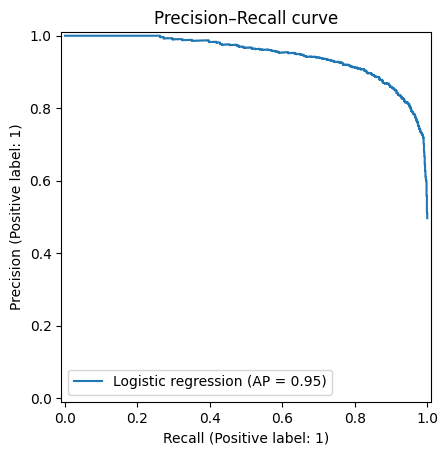

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

y_score = model.predict_proba(X_val)[:, 1]
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_score,
    name="Logistic regression",
)
plt.title("Precision–Recall curve")
plt.show()

In [ ]:
def predict(text: str, model: 'BaseEstimator') -> float:
  tokens = preprocess(text)
  features = bag_of_ngrams(tokens, ngrams_vocab)
  features = np.array([features])
  prob_neg, prob_pos = model.predict_proba(features)[0]
  return prob_pos

In [ ]:
threshold = 0.5
predict("I liked that movie!", model) > threshold

np.True_

In [ ]:
negative_probability = predict("The movie is terrible ", model)
assert 0.0 <= negative_probability <= 1.0
negative_probability > threshold

np.False_

# 5 scikit-learn

До цього моменту ми власноруч писали функції для препроцесінгу даних. Це добре для навчання, але в реальності використовують готові імплементації.

Наприклад, клас [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) з пакету scikit-learn вміє робити майже все з написаного нами:

In [ ]:
import datasets
dataset = datasets.load_dataset('stanfordnlp/imdb')
train_data = dataset['train']
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    max_features=1000,
    ngram_range=(1,3),
    binary=False,
    stop_words=STOP_WORDS,
    # vocabulary=vocab.tokens,
    )
X_train = vectorizer.fit_transform(train_data[:]["text"])

In [ ]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2034128 stored elements and shape (25000, 1000)>

In [ ]:
vectorizer.get_feature_names_out()

array(['10', '20', 'able', 'about', 'about movie', 'above', 'absolutely',
       'across', 'act', 'acted', 'acting', 'action', 'actor', 'actors',
       'actress', 'actual', 'actually', 'add', 'after', 'again',
       'against', 'age', 'ago', 'all', 'all time', 'almost', 'alone',
       'along', 'already', 'also', 'although', 'always', 'am', 'amazing',
       'america', 'american', 'among', 'an', 'animation', 'annoying',
       'another', 'any', 'anyone', 'anything', 'anyway', 'apparently',
       'appears', 'aren', 'around', 'art', 'at', 'at all', 'at end',
       'at least', 'at time', 'at times', 'atmosphere', 'attempt',
       'attention', 'audience', 'average', 'avoid', 'away', 'away from',
       'awful', 'baby', 'back', 'bad', 'badly', 'based', 'based on',
       'basically', 'be', 'beautiful', 'became', 'because', 'become',
       'becomes', 'been', 'before', 'begin', 'beginning', 'begins',
       'behind', 'being', 'believable', 'believe', 'best', 'better',
       'better than

In [ ]:
%%time
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression(solver='liblinear', C=0.1, l1_ratio=1)
model2.fit(X_train, train_data["label"])

CPU times: user 597 ms, sys: 0 ns, total: 597 ms
Wall time: 602 ms


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing '

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def classification_metrics(y_true, y_pred):
  return {
      "accuracy": accuracy_score(y_true, y_pred),
      "precision": precision_score(y_true, y_pred),
      "recall": recall_score(y_true, y_pred),
      "f1": f1_score(y_true, y_pred),
  }

valid_data = dataset["test"].shuffle(seed=1).filter(lambda x, i: i < 2000, with_indices=True)
X_valid = vectorizer.transform(valid_data["text"])
y_valid = valid_data["label"]

y_pred = model2.predict(X_valid)
classification_metrics(y_valid, y_pred)

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

{'accuracy': 0.853,
 'precision': 0.836381135707411,
 'recall': 0.8751258811681772,
 'f1': 0.8553149606299213}

## TF-IDF with sklearn

In [ ]:
%%time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    # binary=True,
    # stop_words='english',
    # vocabulary=vocab.tokens,
    )
X_train = vectorizer.fit_transform(train_data[:]["text"])

model3 = LogisticRegression(solver='liblinear', C=0.2, l1_ratio=1)
model3.fit(X_train, train_data["label"])


X_valid = vectorizer.transform(valid_data["text"])
y_valid = valid_data["label"]
y_pred = model3.predict(X_valid)
classification_metrics(y_valid, y_pred)

CPU times: user 20.2 s, sys: 123 ms, total: 20.3 s
Wall time: 20.4 s


{'accuracy': 0.835,
 'precision': 0.8089468779123952,
 'recall': 0.8741188318227593,
 'f1': 0.8402710551790901}

In [ ]:
import time
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

train_texts = train_data["text"]
y_train = train_data["label"]

valid_texts = valid_data["text"]
y_valid = valid_data["label"]

experiments = [
    {
        "Модель": "Logistic regression",
        "Ознаки": "CountVectorizer",
        "max_features": 1000,
        "ngram_range": (1, 2),
    },
    {
        "Модель": "Logistic regression",
        "Ознаки": "CountVectorizer",
        "max_features": 5000,
        "ngram_range": (1, 2),
    },
    {
        "Модель": "Logistic regression",
        "Ознаки": "CountVectorizer",
        "max_features": 10000,
        "ngram_range": (1, 2),
    },
    {
        "Модель": "Logistic regression",
        "Ознаки": "CountVectorizer",
        "max_features": 20000,
        "ngram_range": (1, 2),
    },
    {
        "Модель": "Logistic regression",
        "Ознаки": "TF-IDF",
        "max_features": 10000,
        "ngram_range": (1, 2),
    },
    {
        "Модель": "Logistic regression",
        "Ознаки": "TF-IDF",
        "max_features": 10000,
        "ngram_range": (1, 1),
    },
    {
        "Модель": "Logistic regression",
        "Ознаки": "TF-IDF",
        "max_features": 10000,
        "ngram_range": (1, 3),
    },
    {
        "Модель": "Logistic regression",
        "Ознаки": "TF-IDF (sublinear)",
        "max_features": 20000,
        "ngram_range": (1, 2),
        "sublinear_tf": True, ##параметр tf модифікований: tf_sublinear = 1 + ln(tf), tf > 0
    },
]

results = []

for exp in experiments:
  if "TF-IDF" in exp["Ознаки"]:
    vectorizer = TfidfVectorizer(
        max_features=exp["max_features"],
        ngram_range=exp["ngram_range"],
        sublinear_tf=exp.get("sublinear_tf", False),
    )
  else:
    vectorizer = CountVectorizer(
        max_features=exp["max_features"], ngram_range=exp["ngram_range"]
    )

  X_train = vectorizer.fit_transform(train_texts)
  X_valid = vectorizer.transform(valid_texts)

  model = LogisticRegression(solver="liblinear", C=0.2, random_state=42)

  start_time = time.time()
  model.fit(X_train, y_train)
  fit_duration = time.time() - start_time

  y_pred = model.predict(X_valid)

  results.append({
      "Модель": exp["Модель"],
      "Ознаки": exp["Ознаки"],
      "max_features": exp["max_features"],
      "ngram_range": str(exp["ngram_range"]),
      "Accuracy": round(accuracy_score(y_valid, y_pred), 4),
      "Precision": round(precision_score(y_valid, y_pred), 4),
      "Recall": round(recall_score(y_valid, y_pred), 4),
      "F1": round(f1_score(y_valid, y_pred), 4),
      "Час навчання": f"{round(fit_duration, 2)} с",
  })

df_results = pd.DataFrame(results)
df_results

,Модель,Ознаки,max_features,ngram_range,Accuracy,Precision,Recall,F1,Час навчання
0,Logistic regression,CountVectorizer,1000,"(1, 2)",0.8445,0.8279,0.8671,0.8470,2.16 с
1,Logistic regression,CountVectorizer,5000,"(1, 2)",0.8730,0.8612,0.8872,0.8740,2.84 с
2,Logistic regression,CountVectorizer,10000,"(1, 2)",0.8815,0.8706,0.8943,0.8823,4.78 с
3,Logistic regression,CountVectorizer,20000,"(1, 2)",0.8880,0.8788,0.8983,0.8884,4.45 с
4,Logistic regression,TF-IDF,10000,"(1, 2)",0.8805,0.8660,0.8983,0.8819,0.78 с
5,Logistic regression,TF-IDF,10000,"(1, 1)",0.8690,0.8566,0.8842,0.8702,0.63 с
6,Logistic regression,TF-IDF,10000,"(1, 3)",0.8795,0.8636,0.8993,0.8811,0.79 с
7,Logistic regression,TF-IDF (sublinear),20000,"(1, 2)",0.8865,0.8726,0.9033,0.8877,0.83 с


In [ ]:
df_sorted = df_results.sort_values(
    by="F1", ascending=False
).reset_index(drop=True)
df_sorted

,Модель,Ознаки,max_features,ngram_range,Accuracy,Precision,Recall,F1,Час навчання
0,Logistic regression,CountVectorizer,20000,"(1, 2)",0.8880,0.8788,0.8983,0.8884,4.45 с
1,Logistic regression,TF-IDF (sublinear),20000,"(1, 2)",0.8865,0.8726,0.9033,0.8877,0.83 с
2,Logistic regression,CountVectorizer,10000,"(1, 2)",0.8815,0.8706,0.8943,0.8823,4.78 с
3,Logistic regression,TF-IDF,10000,"(1, 2)",0.8805,0.8660,0.8983,0.8819,0.78 с
4,Logistic regression,TF-IDF,10000,"(1, 3)",0.8795,0.8636,0.8993,0.8811,0.79 с
5,Logistic regression,CountVectorizer,5000,"(1, 2)",0.8730,0.8612,0.8872,0.8740,2.84 с
6,Logistic regression,TF-IDF,10000,"(1, 1)",0.8690,0.8566,0.8842,0.8702,0.63 с
7,Logistic regression,CountVectorizer,1000,"(1, 2)",0.8445,0.8279,0.8671,0.8470,2.16 с


В межах CountVectorizer бачимо залежність, що розширення розміру словника дійсно покращує точність роботи моделі, однак значне покращення спостерігається саме на перших етапах розширеня від 1000 до 5000, а далі якість починає зростати слабко (через додавання великої кількості рідких, малоінформативних слів). Також бачимо, що на даному датасеті розширення до триграм не дає покращення результату і оптимальним є використання біграм (уніграм тут буде мало для забезпечення оптимальної якості). Також бачимо, що тут TF-IDF не дає покращення якості на даному датасеті, але працює набагато швидше. І бачимо, що сублінійний TF дійсно показав приріст якості.

## Завдання: порівняйте представлення тексту

Запустіть кілька варіантів моделі за однакового розбиття даних і заповніть таблицю.

| Модель | Ознаки | `max_features` | `ngram_range` | Accuracy | Precision | Recall | F1 | Час навчання |
|---|---|---:|:---:|---:|---:|---:|---:|---:|
| Logistic regression | CountVectorizer | 1000 | (1, 2) | — | — | — | — | — |
| Logistic regression | CountVectorizer | 5000 | (1, 2) | — | — | — | — | — |
| Logistic regression | CountVectorizer | 10000 | (1, 2) | — | — | — | — | — |
| Logistic regression | CountVectorizer | 20000 | (1, 2) | — | — | — | — | — |
| Logistic regression | TF-IDF | 10000 | (1, 2) | — | — | — | — | — |
| Logistic regression | TF-IDF | 10000 | (1, 1) | — | — | — | — | — |
| Logistic regression | TF-IDF | 10000 | (1, 3) | — | — | — | — | — |
| Ваш варіант | … | … | … | — | — | — | — | — |

Коротко підсумуйте результати експериментів. Як кількість ознак впливає на якість? Як вплинуло додавання біграм та триграм? Який результат дали TF-IDF ознаки порівнянно з простою кількістю зустрічань?